In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

if os.environ['GROQ_API_KEY']:
    print("API Key is Set!!!")
else:
    raise ValueError("API Key not loaded!!!")

API Key is Set!!!


In [2]:
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000225D9C992B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000225D9DE0800>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
from langchain_core.messages import HumanMessage, AIMessage

llm.invoke([HumanMessage(content="What is AI")]).content

'**Artificial Intelligence (AI)** is a branch of computer science that focuses on creating systems capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and even creativity.\n\n### Core Concepts\n\n| Concept | What It Means | Example |\n|---------|---------------|---------|\n| **Machine Learning (ML)** | Algorithms that improve automatically through experience (data). | Spam filters that get better at catching unwanted email. |\n| **Deep Learning** | A subset of ML that uses multi‑layer neural networks to model complex patterns. | Voice assistants recognizing spoken commands. |\n| **Natural Language Processing (NLP)** | Techniques for computers to understand, generate, and interact using human language. | Chatbots, translation services. |\n| **Computer Vision** | Enabling machines to interpret visual information from images or video. | Facial‑recognition systems, self‑driving c

In [5]:
from typing import List, Annotated, TypedDict
from operator import add

class graph_schema(TypedDict):
    messages_manual: List
    # messages_auto: Annotated[List,add]

In [11]:
def create_post(state: graph_schema) -> graph_schema:
    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response_manual_ai]

    return state

In [12]:
def curate_post(state: graph_schema) -> graph_schema:
    messages_manual = state['messages_manual']

    response_manual = llm.invoke(messages_manual).content
    response_manual_ai = AIMessage(content=response_manual)

    state['messages_manual'] = messages_manual + [response_manual_ai]

    return state

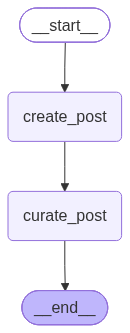

In [13]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post", END)

messages_graph = graph.compile()

Image(messages_graph.get_graph().draw_mermaid_png())

In [14]:
messages_graph.invoke({
    "messages_manual":[HumanMessage(content="What is the importance of AI?")]
})

{'messages_manual': [HumanMessage(content='What is the importance of AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='**Artificial Intelligence (AI) is reshaping virtually every facet of modern life.** Its importance can be understood through several inter‑related lenses—technological, economic, social, scientific, and ethical. Below is a structured overview that highlights why AI matters today and what it promises for the future.\n\n---\n\n## 1. Economic Engine & Productivity Booster\n| Aspect | How AI Adds Value | Real‑World Example |\n|--------|-------------------|--------------------|\n| **Automation of Routine Tasks** | Reduces human labor on repetitive, low‑skill work, freeing up time for higher‑value activities. | Robotic Process Automation (RPA) in banking for transaction processing. |\n| **Intelligent Decision Support** | Analyzes massive datasets to surface insights that humans would miss, enabling faster, data‑driven decisions. | Predictive maintenance

In [15]:
import pprint

pprint.pprint(messages_graph.invoke({
    "messages_manual":[HumanMessage(content="What is the importance of AI?")]
}))

{'messages_manual': [HumanMessage(content='What is the importance of AI?', additional_kwargs={}, response_metadata={}),
                     AIMessage(content='**Artificial Intelligence (AI) is reshaping virtually every aspect of modern life.** Its importance can be understood through several inter‑related dimensions:\n\n---\n\n## 1. Economic Impact\n| Area | Why It Matters |\n|------|----------------|\n| **Productivity & Automation** | AI automates repetitive tasks, freeing human workers for higher‑value activities and dramatically increasing output. |\n| **New Business Models** | Platforms such as recommendation engines, autonomous logistics, and AI‑as‑a‑service enable entirely new revenue streams. |\n| **Growth & Competitiveness** | Nations and companies that adopt AI faster tend to see higher GDP growth, higher wages for skilled workers, and a stronger position in global markets. |\n\n---\n\n## 2. Societal Benefits\n- **Healthcare:** Early disease detection (e.g., radiology, pathol